## 1. Install Required Libraries

Run once per environment (Colab or local venv).

In [1]:
!pip install -q tensorflow opencv-python scikit-learn matplotlib pandas numpy pillow tqdm lime scikit-image


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [2]:
import os
import cv2
import json
import random
import warnings
from glob import glob
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    roc_auc_score, matthews_corrcoef, cohen_kappa_score,
)
from sklearn.preprocessing import label_binarize

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))


c:\Users\ASUS\OneDrive\Desktop\SkinNova A Novel Deep Learning Framework for Skin Cancer Detection and Explainable Diagnosis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.21.0
GPUs available: []


## 3. Reproducibility Settings

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


In [4]:
# ===================== USER CONFIG =====================
DATASET_DIR = r"C:\Users\ASUS\OneDrive\Desktop\SkinNova A Novel Deep Learning Framework for Skin Cancer Detection and Explainable Diagnosis\Dataset"          # <-- CHANGE THIS
OUTPUT_DIR  = r"C:\Users\ASUS\OneDrive\Desktop\SkinNova A Novel Deep Learning Framework for Skin Cancer Detection and Explainable Diagnosis\Outputs" # <-- CHANGE THIS
MODEL_NAME  = "SkinNova_Hybrid_EffNetV2_Transformer"

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 7
EPOCHS_STAGE_1 = 20
EPOCHS_STAGE_2 = 20
LEARNING_RATE_STAGE_1 = 1e-4
LEARNING_RATE_STAGE_2 = 1e-5
FINE_TUNE_LAST_N_LAYERS = 40
USE_MIXED_PRECISION = True

TRANSFORMER_LAYERS = 2
TRANSFORMER_HEADS = 4
TRANSFORMER_DIM = 256

BLUR_REJECT_THRESHOLD = 15.0   # Laplacian-variance threshold for low-quality image flagging
# =========================================================================

for sub in ["models", "graphs", "csv", "gradcam", "lime", "reports", "preprocessed_cache"]:
    os.makedirs(os.path.join(OUTPUT_DIR, sub), exist_ok=True)

METADATA_PATH = os.path.join(DATASET_DIR, "HAM10000_metadata.csv")
IMAGE_DIR_1 = os.path.join(DATASET_DIR, "HAM10000_images_part_1")
IMAGE_DIR_2 = os.path.join(DATASET_DIR, "HAM10000_images_part_2")
CACHE_DIR = os.path.join(OUTPUT_DIR, "preprocessed_cache")

print("Dataset Directory:", DATASET_DIR)
print("Output Directory:", OUTPUT_DIR)


Dataset Directory: C:\Users\ASUS\OneDrive\Desktop\SkinNova A Novel Deep Learning Framework for Skin Cancer Detection and Explainable Diagnosis\Dataset
Output Directory: C:\Users\ASUS\OneDrive\Desktop\SkinNova A Novel Deep Learning Framework for Skin Cancer Detection and Explainable Diagnosis\Outputs


## 5. Load Metadata and Map Image Paths

In [5]:
if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(f"Metadata file not found: {METADATA_PATH}")

metadata = pd.read_csv(METADATA_PATH)
print("Metadata Shape:", metadata.shape)
display(metadata.head())

LABEL_MAP = {"akiec": 0, "bcc": 1, "bkl": 2, "df": 3, "mel": 4, "nv": 5, "vasc": 6}
CODE_TO_NAME = {
    "akiec": "Actinic Keratosis", "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis", "df": "Dermatofibroma", "mel": "Melanoma",
    "nv": "Melanocytic Nevus", "vasc": "Vascular Lesion",
}
TARGET_NAMES = [CODE_TO_NAME[c] for c in sorted(LABEL_MAP, key=LABEL_MAP.get)]
HIGH_RISK_CLASSES = {"Melanoma", "Basal Cell Carcinoma", "Actinic Keratosis"}

metadata["label"] = metadata["dx"].map(LABEL_MAP)
metadata["disease_name"] = metadata["dx"].map(CODE_TO_NAME)

image_paths = {}
for folder in [IMAGE_DIR_1, IMAGE_DIR_2]:
    for path in glob(os.path.join(folder, "*.jpg")):
        image_id = os.path.splitext(os.path.basename(path))[0]
        image_paths[image_id] = path

metadata["image_path"] = metadata["image_id"].map(image_paths)
before = len(metadata)
metadata = metadata.dropna(subset=["image_path", "label"]).reset_index(drop=True)
metadata["label"] = metadata["label"].astype(int)
print(f"Dropped {before - len(metadata)} rows with missing image/label.")

print("Total Images Found:", len(metadata))
print(metadata["dx"].value_counts())
metadata.to_csv(os.path.join(OUTPUT_DIR, "csv", "full_metadata_with_paths.csv"), index=False)


Metadata Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Dropped 0 rows with missing image/label.
Total Images Found: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


## 6. Dataset Class Distribution Graph and CSV

,dx,disease_name,count
0,akiec,Actinic Keratosis,327
1,bcc,Basal Cell Carcinoma,514
2,bkl,Benign Keratosis,1099
3,df,Dermatofibroma,115
4,mel,Melanoma,1113
5,nv,Melanocytic Nevus,6705
6,vasc,Vascular Lesion,142


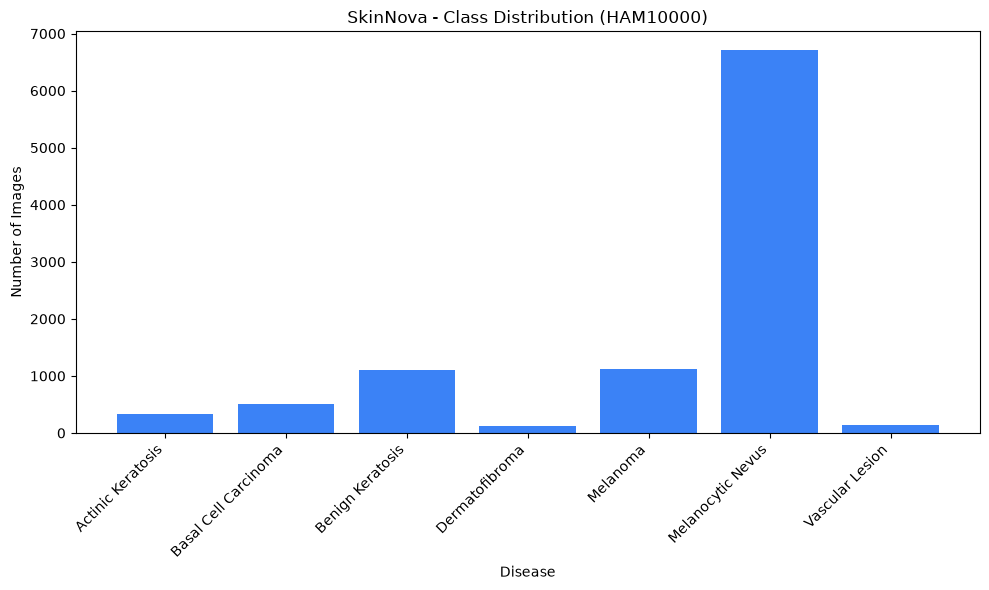

In [6]:
class_distribution = metadata.groupby(["dx", "disease_name"]).size().reset_index(name="count")
class_distribution.to_csv(os.path.join(OUTPUT_DIR, "csv", "class_distribution.csv"), index=False)
display(class_distribution)

plt.figure(figsize=(10, 6))
plt.bar(class_distribution["disease_name"], class_distribution["count"], color="#3b82f6")
plt.xticks(rotation=45, ha="right")
plt.title("SkinNova - Class Distribution (HAM10000)")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "graphs", "class_distribution.png"), dpi=300)
plt.show()


## 7. Train, Validation, and Test Split (Stratified)

In [7]:
train_df, temp_df = train_test_split(
    metadata, test_size=0.30, stratify=metadata["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))


Train: 7010  Val: 1502  Test: 1503


## 8. Preprocessing Functions

- **Blur score** — Laplacian variance, used for image-quality flagging.
- **Hair removal** — Dull Razor-style blackhat morphology + inpainting.
- **CLAHE + bilateral filtering** — contrast enhancement while preserving lesion edges.


In [8]:
def blur_score_rgb(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


def hair_removal_dull_razor(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(image_rgb, mask, 1, cv2.INPAINT_TELEA)


def enhance_clahe_bilateral(image_rgb):
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
    return cv2.bilateralFilter(enhanced, 9, 75, 75)


def preprocess_image_full(path, img_size=IMG_SIZE):
    '''Full CPU preprocessing pipeline. Returns (uint8 RGB image, blur score).'''
    image_bgr = cv2.imread(path)
    if image_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    quality = blur_score_rgb(image_rgb)
    image_rgb = hair_removal_dull_razor(image_rgb)
    image_rgb = enhance_clahe_bilateral(image_rgb)
    image_rgb = cv2.resize(image_rgb, (img_size, img_size), interpolation=cv2.INTER_AREA)
    return image_rgb, quality


## 9. Build Preprocessing Cache (runs once)

This is the key fix vs. the previous notebook: hair removal / CLAHE / bilateral filtering used to run
inside the `tf.data` pipeline on every single epoch. Here it runs **once**, and the result is cached to
disk as small JPEGs — training then just decodes a cached image instead of redoing this CPU-heavy
pipeline tens of times over.

Re-running this cell later is cheap: already-cached images are skipped.


In [9]:
quality_rows = []
cached_paths = {}

for row in tqdm(metadata.itertuples(), total=len(metadata), desc="Preprocessing & caching"):
    out_path = os.path.join(CACHE_DIR, f"{row.image_id}.jpg")
    cached_paths[row.image_id] = out_path
    if os.path.exists(out_path):
        continue
    try:
        processed, quality = preprocess_image_full(row.image_path)
        cv2.imwrite(out_path, cv2.cvtColor(processed, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, 95])
        quality_rows.append({"image_id": row.image_id, "blur_score": quality})
    except Exception as e:
        print(f"Failed to preprocess {row.image_path}: {e}")

metadata["cached_path"] = metadata["image_id"].map(cached_paths)
train_df["cached_path"] = train_df["image_id"].map(cached_paths)
val_df["cached_path"] = val_df["image_id"].map(cached_paths)
test_df["cached_path"] = test_df["image_id"].map(cached_paths)

if quality_rows:
    quality_df = pd.DataFrame(quality_rows)
    quality_df.to_csv(os.path.join(OUTPUT_DIR, "csv", "image_quality_scores.csv"), index=False)
    low_quality = (quality_df["blur_score"] < BLUR_REJECT_THRESHOLD).sum()
    print(f"Quality assessment: {low_quality}/{len(quality_df)} newly processed images flagged as low quality "
          f"(blur score < {BLUR_REJECT_THRESHOLD}).")
else:
    print("All images were already cached from a previous run.")


Preprocessing & caching:  46%|████▋     | 4635/10015 [06:33<07:37, 11.77it/s]


KeyboardInterrupt: 

## 10. TensorFlow Dataset Pipeline (reads cached, already-preprocessed images)

In [ ]:
def _decode_cached_image(path, label, img_size=IMG_SIZE):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (img_size, img_size))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def create_dataset(df, shuffle=True):
    paths = df["cached_path"].values
    labels = df["label"].values.astype(np.int64)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_decode_cached_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 4000), seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)
test_ds = create_dataset(test_df, shuffle=False)

print("Datasets created successfully.")


Datasets created successfully.


## 11. Visualize Sample Preprocessing

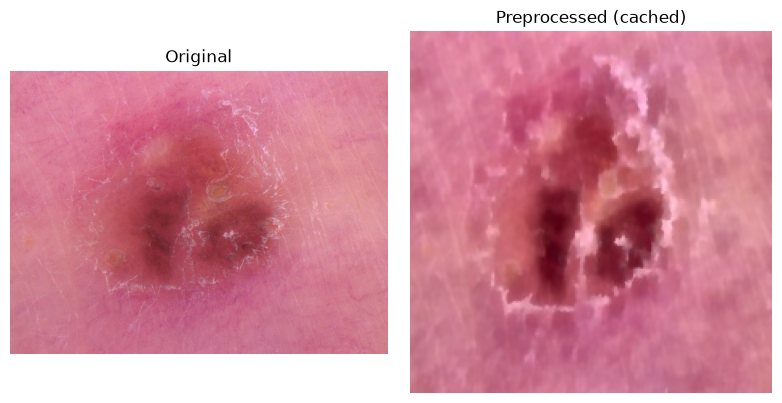

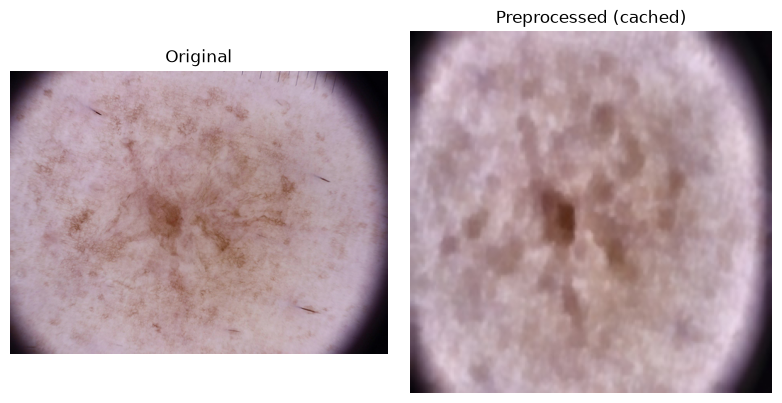

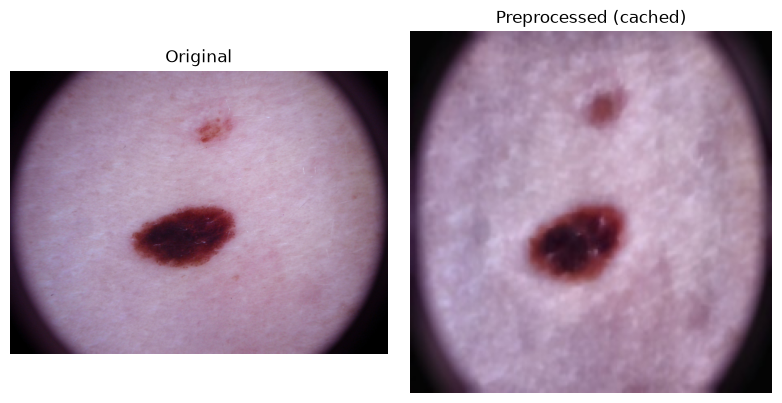

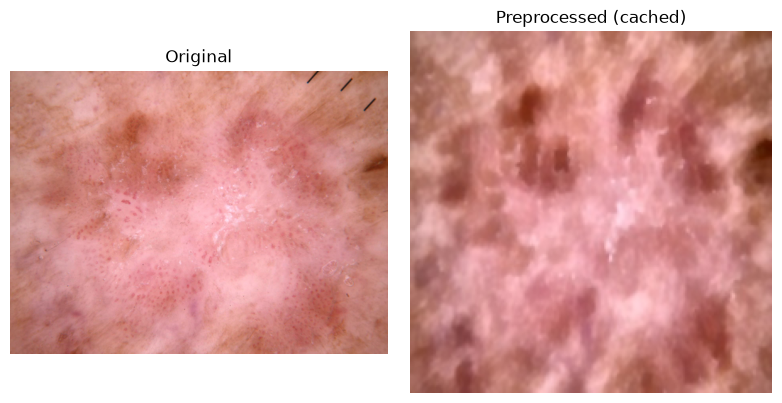

In [ ]:
sample_paths = train_df.sample(4, random_state=SEED)[["image_path", "cached_path"]].values

for original_path, cached_path in sample_paths:
    original = cv2.cvtColor(cv2.imread(original_path), cv2.COLOR_BGR2RGB)
    processed = cv2.cvtColor(cv2.imread(cached_path), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(processed)
    plt.title("Preprocessed (cached)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


## 12. Class Weights for Imbalance Handling

In [ ]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"],
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}

class_weight_df = pd.DataFrame({
    "label": list(class_weights.keys()),
    "disease_name": [TARGET_NAMES[i] for i in class_weights.keys()],
    "weight": list(class_weights.values()),
})
class_weight_df.to_csv(os.path.join(OUTPUT_DIR, "csv", "class_weights.csv"), index=False)
display(class_weight_df)


,label,disease_name,weight
0,0,Actinic Keratosis,4.373051
1,1,Basal Cell Carcinoma,2.781746
2,2,Benign Keratosis,1.302248
3,3,Dermatofibroma,12.363316
4,4,Melanoma,1.285531
5,5,Melanocytic Nevus,0.213388
6,6,Vascular Lesion,10.115440


## 13. Data Augmentation Layer

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name="SkinNova_Augmentation")


## 14. Build Hybrid Model: EfficientNetV2B0 + Transformer Encoder

EfficientNetV2B0 produces a spatial feature map (local, texture-level features). That feature map is
flattened into a sequence of tokens and passed through a small Transformer encoder to capture long-range,
global contextual relationships across the lesion — similar in spirit to a Vision Transformer branch, but
built directly on the CNN's own feature map instead of requiring a separate large pretrained ViT backbone.
The Transformer's pooled output is fused with the CNN's global-average-pooled features before classification.


In [ ]:
def transformer_encoder_block(x, num_heads, key_dim, ff_dim, dropout=0.1, name="transformer_block"):
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=dropout, name=f"{name}_mha"
    )(x, x)
    x = layers.Add(name=f"{name}_add1")([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x)

    ff = layers.Dense(ff_dim, activation="gelu", name=f"{name}_ff1")(x)
    ff = layers.Dropout(dropout, name=f"{name}_ff_drop")(ff)
    ff = layers.Dense(x.shape[-1], name=f"{name}_ff2")(ff)
    x = layers.Add(name=f"{name}_add2")([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x)
    return x


def build_hybrid_model():
    base_model = EfficientNetV2B0(
        include_top=False, weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
    x = data_augmentation(inputs)
    feature_map = base_model(x, training=False)  # (B, H, W, C)

    # --- CNN branch ---
    cnn_features = layers.GlobalAveragePooling2D(name="cnn_gap")(feature_map)
    cnn_features = layers.BatchNormalization(name="cnn_bn")(cnn_features)

    # --- Transformer branch ---
    h, w, c = feature_map.shape[1], feature_map.shape[2], feature_map.shape[3]
    tokens = layers.Reshape((h * w, c), name="tokens_reshape")(feature_map)
    tokens = layers.Dense(TRANSFORMER_DIM, name="token_projection")(tokens)

    num_positions = h * w
    pos_embedding = layers.Embedding(
        input_dim=num_positions, output_dim=TRANSFORMER_DIM, name="positional_embedding"
    )(tf.range(start=0, limit=num_positions, delta=1))
    tokens = tokens + pos_embedding

    for i in range(TRANSFORMER_LAYERS):
        tokens = transformer_encoder_block(
            tokens, num_heads=TRANSFORMER_HEADS,
            key_dim=TRANSFORMER_DIM // TRANSFORMER_HEADS,
            ff_dim=TRANSFORMER_DIM * 2, name=f"transformer_block_{i}",
        )
    transformer_features = layers.GlobalAveragePooling1D(name="transformer_gap")(tokens)

    # --- Feature fusion ---
    fused = layers.Concatenate(name="feature_fusion")([cnn_features, transformer_features])
    x = layers.Dense(512, activation="relu", name="dense_512")(fused)
    x = layers.Dropout(0.4, name="dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32", name="skin_lesion_output")(x)

    model = models.Model(inputs, outputs, name=MODEL_NAME)
    return model, base_model


if USE_MIXED_PRECISION:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")

model, base_model = build_hybrid_model()
model.summary()


Model: "SkinNova_Hybrid_EffNetV2_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SkinNova_Augmentat… │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 7, 7,      │  5,919,312 │ SkinNova_Augment… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tokens_reshape      │ (None, 49, 1280)  │          0 │ efficientnetv2-b… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_projection    │ (None, 49, 256)   │    327,936 │ tokens_reshape[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 256)   │          0 │ token_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 256)   │    263,168 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 256)   │          0 │ add[0][0],        │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 256)   │        512 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 512)   │    131,584 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 512)   │          0 │ transformer_bloc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 256)   │    131,328 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 256)   │          0 │ transformer_bloc… │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 256)   │        512 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 256)   │    263,168 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 256)   │          0 │ transformer_bloc… │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 49, 256)   │        512 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 8,226,647 (31.38 MB)

 Trainable params: 2,304,775 (8.79 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

## 15. Compile Model (Stage 1)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_STAGE_1),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top_2_accuracy")],
)


## 16. Training Callbacks

In [ ]:
best_model_path = os.path.join(OUTPUT_DIR, "models", "best_skinnova_hybrid.keras")
final_model_path = os.path.join(OUTPUT_DIR, "models", "final_skinnova_hybrid.keras")
training_log_path = os.path.join(OUTPUT_DIR, "csv", "training_log.csv")

callbacks = [
    ModelCheckpoint(best_model_path, monitor="val_accuracy", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    CSVLogger(training_log_path, append=True),
]


## 17. Stage 1 Training: Frozen EfficientNetV2B0 Backbone

In [ ]:
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_1,
    class_weight=class_weights,
    callbacks=callbacks,
)


Epoch 1/20
 73/220 ━━━━━━━━━━━━━━━━━━━━ 3:38 1s/step - accuracy: 0.1562 - loss: 2.2003 - top_2_accuracy: 0.3112

## 18. Stage 2 Fine-Tuning

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-FINE_TUNE_LAST_N_LAYERS]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_STAGE_2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top_2_accuracy")],
)

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_2,
    class_weight=class_weights,
    callbacks=callbacks,
)

model.save(final_model_path)
print("Saved final model to:", final_model_path)


## 19. Combine Training History and Save CSV

In [ ]:
def history_to_df(history, stage_name, epoch_offset):
    df = pd.DataFrame(history.history)
    df["epoch"] = np.arange(1, len(df) + 1)
    df["global_epoch"] = df["epoch"] + epoch_offset
    df["stage"] = stage_name
    return df

history_df_1 = history_to_df(history_1, "frozen_backbone", 0)
history_df_2 = history_to_df(history_2, "fine_tuning", len(history_df_1))
history_df = pd.concat([history_df_1, history_df_2], ignore_index=True)
history_df.to_csv(os.path.join(OUTPUT_DIR, "csv", "training_history.csv"), index=False)
display(history_df.tail())


## 20. Accuracy, Loss, and Top-2 Accuracy Graphs

In [ ]:
def plot_metric(history_df, train_col, val_col, title, ylabel, filename):
    plt.figure(figsize=(9, 5))
    plt.plot(history_df["global_epoch"], history_df[train_col], label=train_col)
    plt.plot(history_df["global_epoch"], history_df[val_col], label=val_col)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "graphs", filename), dpi=300)
    plt.show()

plot_metric(history_df, "accuracy", "val_accuracy", "SkinNova Accuracy", "Accuracy", "accuracy_curve.png")
plot_metric(history_df, "loss", "val_loss", "SkinNova Loss", "Loss", "loss_curve.png")
plot_metric(history_df, "top_2_accuracy", "val_top_2_accuracy", "SkinNova Top-2 Accuracy", "Top-2 Accuracy", "top2_accuracy_curve.png")


## 21. Load Best Model and Evaluate Test Set

In [ ]:
best_model = tf.keras.models.load_model(best_model_path)

test_results = best_model.evaluate(test_ds, verbose=1)
print("Test Results:", test_results)

metric_names = best_model.metrics_names
test_metrics_df = pd.DataFrame({"metric": metric_names, "value": test_results})
test_metrics_df.to_csv(os.path.join(OUTPUT_DIR, "csv", "test_metrics.csv"), index=False)
display(test_metrics_df)


## 22. Generate Predictions CSV

In [ ]:
y_true, y_pred, y_prob = [], [], []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

prediction_df = test_df.copy().reset_index(drop=True)
prediction_df["true_class"] = [TARGET_NAMES[i] for i in y_true]
prediction_df["predicted_class"] = [TARGET_NAMES[i] for i in y_pred]
prediction_df["confidence"] = y_prob.max(axis=1)
prediction_df.to_csv(os.path.join(OUTPUT_DIR, "csv", "predictions.csv"), index=False)
display(prediction_df.head())


## 23. Classification Report CSV

In [ ]:
report_dict = classification_report(
    y_true, y_pred, target_names=TARGET_NAMES, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(OUTPUT_DIR, "csv", "classification_report.csv"), index=True)
display(report_df)


## 24. Confusion Matrix CSV and Graph

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=TARGET_NAMES, columns=TARGET_NAMES)
cm_df.to_csv(os.path.join(OUTPUT_DIR, "csv", "confusion_matrix.csv"))
display(cm_df)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.title("SkinNova Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(TARGET_NAMES)), TARGET_NAMES, rotation=90)
plt.yticks(range(len(TARGET_NAMES)), TARGET_NAMES)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "graphs", "confusion_matrix.png"), dpi=300)
plt.show()


## 25. Advanced Overall Metrics CSV

In [ ]:
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

try:
    roc_auc_macro = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
    roc_auc_weighted = roc_auc_score(y_true_bin, y_prob, average="weighted", multi_class="ovr")
except Exception:
    roc_auc_macro = roc_auc_weighted = float("nan")

overall_metrics = {
    "accuracy": float((y_true == y_pred).mean()),
    "mcc": float(matthews_corrcoef(y_true, y_pred)),
    "cohen_kappa": float(cohen_kappa_score(y_true, y_pred)),
    "roc_auc_macro": float(roc_auc_macro),
    "roc_auc_weighted": float(roc_auc_weighted),
}
overall_metrics_df = pd.DataFrame([overall_metrics])
overall_metrics_df.to_csv(os.path.join(OUTPUT_DIR, "csv", "overall_metrics.csv"), index=False)
display(overall_metrics_df)


## 26. Per-Class Sensitivity, Specificity, Precision, Recall, F1 CSV

In [ ]:
per_class_rows = []

for i, class_name in enumerate(TARGET_NAMES):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    precision = report_dict[class_name]["precision"]
    recall = report_dict[class_name]["recall"]
    f1 = report_dict[class_name]["f1-score"]

    per_class_rows.append({
        "class": class_name, "sensitivity": sensitivity, "specificity": specificity,
        "precision": precision, "recall": recall, "f1_score": f1,
    })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(os.path.join(OUTPUT_DIR, "csv", "per_class_metrics.csv"), index=False)
display(per_class_df)


## 27. ROC Curves and AUC CSV

In [ ]:
roc_rows = []
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(TARGET_NAMES):
    fpr, tpr, thresholds = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    roc_df = pd.DataFrame({"class_id": i, "class_name": class_name, "fpr": fpr, "tpr": tpr})
    roc_rows.append(roc_df)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("SkinNova ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "graphs", "roc_curves.png"), dpi=300)
plt.show()

pd.concat(roc_rows, ignore_index=True).to_csv(os.path.join(OUTPUT_DIR, "csv", "roc_curve_points.csv"), index=False)


## 28. Confidence Distribution and Misclassification Analysis

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(prediction_df["confidence"], bins=30, color="#3b82f6")
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of Test Images")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "graphs", "confidence_distribution.png"), dpi=300)
plt.show()

misclassified_df = prediction_df[prediction_df["true_class"] != prediction_df["predicted_class"]]
misclassified_df.to_csv(os.path.join(OUTPUT_DIR, "csv", "misclassified_samples.csv"), index=False)
print(f"Misclassified: {len(misclassified_df)} / {len(prediction_df)} "
      f"({100 * len(misclassified_df) / len(prediction_df):.2f}%)")


## 29. Class-Wise Confidence Graph

In [ ]:
class_confidence = prediction_df.groupby("true_class")["confidence"].agg(
    ["mean", "median", "std", "count"]
).reset_index()
class_confidence.to_csv(os.path.join(OUTPUT_DIR, "csv", "class_confidence_summary.csv"), index=False)
display(class_confidence)

plt.figure(figsize=(10, 6))
plt.bar(class_confidence["true_class"], class_confidence["mean"], yerr=class_confidence["std"], capsize=4)
plt.xticks(rotation=45, ha="right")
plt.title("Mean Prediction Confidence by True Class")
plt.ylabel("Mean Confidence")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "graphs", "class_confidence.png"), dpi=300)
plt.show()


## 30. Grad-CAM Explainability (fixed)

EfficientNetV2B0 is itself a Keras **Functional** model with named layers, so we can build the Grad-CAM
sub-model directly from `base_model`'s own input/output — no nested-submodel search or fallback logic needed,
unlike the previous notebook version.


In [ ]:
def find_last_conv_layer_name(base_model):
    for layer in reversed(base_model.layers):
        if len(layer.output.shape) == 4:
            return layer.name
    raise ValueError("No 4D (conv) layer found in base model.")


def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name=None):
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer_name(base_model)

    grad_model = tf.keras.models.Model(
        base_model.inputs, [base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, _ = grad_model(img_array, training=False)
        preds = model(img_array, training=False)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    if grads is None:
        raise ValueError("Gradients are None - check that base_model is reachable from model's graph.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def save_gradcam_overlay(image_path, save_path, model, base_model):
    processed, _ = preprocess_image_full(image_path)
    img_array = np.expand_dims(processed.astype(np.float32) / 255.0, axis=0)

    heatmap = make_gradcam_heatmap(img_array, model, base_model)
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(0.6 * processed + 0.4 * heatmap_color)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(processed); axes[0].set_title("Preprocessed"); axes[0].axis("off")
    axes[1].imshow(heatmap_resized, cmap="jet"); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
    axes[2].imshow(overlay); axes[2].set_title("Overlay"); axes[2].axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


for _, row in prediction_df.head(5).iterrows():
    save_path = os.path.join(OUTPUT_DIR, "gradcam", f"gradcam_{row['image_id']}.png")
    try:
        save_gradcam_overlay(row["image_path"], save_path, best_model, base_model)
    except Exception as e:
        print(f"Grad-CAM failed for {row['image_id']}: {e}")


## 31. LIME Explainability

A local, model-agnostic explanation via superpixel perturbation — implemented here rather than just
listed as a planned feature.


In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def lime_explain(image_path, model, save_path, num_samples=1000):
    processed, _ = preprocess_image_full(image_path)
    image_float = processed.astype(np.float32) / 255.0

    def predict_fn(images_batch):
        return model.predict(np.array(images_batch, dtype=np.float32), verbose=0)

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        image_float, predict_fn, top_labels=3, hide_color=0, num_samples=num_samples
    )
    top_label = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        top_label, positive_only=True, num_features=8, hide_rest=False
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME explanation: {TARGET_NAMES[top_label]}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


for _, row in prediction_df.head(5).iterrows():
    save_path = os.path.join(OUTPUT_DIR, "lime", f"lime_{row['image_id']}.png")
    try:
        lime_explain(row["image_path"], best_model, save_path)
    except Exception as e:
        print(f"LIME failed for {row['image_id']}: {e}")


## 32. Single Image Prediction with Clinical Recommendation

In [ ]:
def clinical_recommendation(prediction_class, confidence):
    confidence_percent = confidence * 100
    if prediction_class in HIGH_RISK_CLASSES and confidence_percent >= 80:
        return "High Risk", "Consult a dermatologist as soon as possible."
    if prediction_class in HIGH_RISK_CLASSES and confidence_percent < 80:
        return "Moderate Risk", "Further clinical examination is recommended."
    return "Low Risk", "Routine clinical monitoring recommended."


def predict_single_image(image_path, model=best_model):
    processed, quality = preprocess_image_full(image_path)
    img_array = np.expand_dims(processed.astype(np.float32) / 255.0, axis=0)
    probs = model.predict(img_array, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    pred_class = TARGET_NAMES[pred_id]
    confidence = float(np.max(probs))
    risk, recommendation = clinical_recommendation(pred_class, confidence)

    result = {
        "image_path": image_path,
        "image_quality_blur_score": quality,
        "low_quality_flag": bool(quality < BLUR_REJECT_THRESHOLD),
        "prediction": pred_class,
        "confidence": confidence,
        "risk": risk,
        "clinical_recommendation": recommendation,
        "class_probabilities": {TARGET_NAMES[i]: float(p) for i, p in enumerate(probs)},
        "disclaimer": "This is an AI-assisted research tool, not a medical diagnosis. Always consult a qualified dermatologist.",
    }
    return result

# Example:
# result = predict_single_image("/path/to/test_image.jpg")
# print(json.dumps(result, indent=2))


## 33. Export Final Experiment Summary JSON

In [ ]:
experiment_summary = {
    "project": "SkinNova",
    "model": MODEL_NAME,
    "dataset": "HAM10000",
    "num_classes": NUM_CLASSES,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_stage_1": EPOCHS_STAGE_1,
    "epochs_stage_2": EPOCHS_STAGE_2,
    "fine_tune_last_n_layers": FINE_TUNE_LAST_N_LAYERS,
    "transformer_layers": TRANSFORMER_LAYERS,
    "transformer_heads": TRANSFORMER_HEADS,
    "transformer_dim": TRANSFORMER_DIM,
    "best_model_path": best_model_path,
    "final_model_path": final_model_path,
    "overall_metrics": overall_metrics,
    "test_metrics": dict(zip(metric_names, test_results)),
}

with open(os.path.join(OUTPUT_DIR, "reports", "experiment_summary.json"), "w") as f:
    json.dump(experiment_summary, f, indent=2)

print(json.dumps(experiment_summary, indent=2))


## 34. Optional: Zip All Outputs for Download

In [ ]:
import shutil
zip_path = shutil.make_archive(os.path.join(OUTPUT_DIR, "..", "SkinNova_Outputs"), "zip", OUTPUT_DIR)
print("ZIP created:", zip_path)
